# Speranza Stefano - 2075518 - 29/01/2026

L'intento di questo progetto è quello di analizzare i risultati dell'apprendimento di reti neurali di tipo MLP, anche al variare di alcuni iperparametri e in aggiunta di rumore.
Le reti verranno addestrate sul dataset MNIST, quindi per il riconoscimento di cifre manoscritte.
Infine, verrà fatta un'analisi di queste reti utilizzando un dataset differente come FashionMNIST, in modo da studiare limiti, analogie e differenze.

# Dataset

Come prima cosa importiamo le librerie per le reti, di supporto e del dataset.

In [1]:
from torchvision.datasets import MNIST

import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

from sklearn.neural_network import MLPClassifier

Dato che MNIST fornisce già i dati di training e di test separati, useremo quelli per semplicità. Sappiamo che la cross validazione permetta di ottenere risultati migliori in caso di dataset scarni, ma MNIST è un dataset sufficientemente adeguato in grandezza. Procediamo quindi a suddividere i dati nei due insiemi e a convertirili in formato matriciale con numpy.

In [2]:
%%capture
mnist_tr = MNIST(root="../mnist",
                 train=True,      # dati di training
                 download=True)
mnist_te = MNIST(root="../mnist",
                 train=False,     # dati di test
                 download=True)

In [3]:
mnist_tr, mnist_tr_labels = mnist_tr.data.numpy(), mnist_tr.targets.numpy()
mnist_te, mnist_te_labels = mnist_te.data.numpy(), mnist_te.targets.numpy()

Le reti di tipo MLP richiedono un input lineare, quindi linearizziamo tutti i pattern, passando da due dimensioni 28x28 ad una sola di grandezza 768.

Inoltre, dato che le immagini sono salvate in formato standard su una scala di grigio da 0 a 255, procediamo con la normalizzazione.

In [4]:
x_tr = mnist_tr.reshape(60000, 28 * 28)
x_te = mnist_te.reshape(10000, 28 * 28)

x_tr = x_tr / 255.0  # il .0 serve a forzare la conversione in float, anche se potrebbe pensarci già python
x_te = x_te / 255.0

Mostriamo un pattern di tranining come esempio:

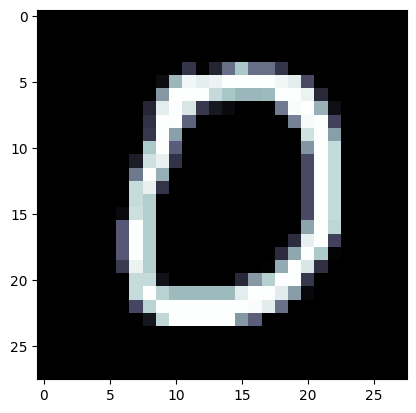

In [5]:
_ = plt.imshow(x_te[10].reshape(28, 28), cmap="bone")

# Addestramento MLP (a)

Addestriamo cinque reti MLP con numero di neuroni differente. Manteniamo due strati nascosti di uguale numero di neuroni, pari a 20, 50, 100, 300 e 500 per ciascuna rete, e analizziamo i risultati.

In [6]:
random_state = 42

MLP20 = MLPClassifier(hidden_layer_sizes=(20, 20),
                    max_iter = 10,
                    random_state=random_state)
MLP50 = MLPClassifier(hidden_layer_sizes=(50, 50),
                    max_iter = 10,
                    random_state=random_state)
MLP100 = MLPClassifier(hidden_layer_sizes=(100, 100),
                    max_iter = 10,
                    random_state=random_state)
MLP300 = MLPClassifier(hidden_layer_sizes=(300, 300),
                    max_iter = 10,
                    random_state=random_state)
MLP500 = MLPClassifier(hidden_layer_sizes=(500, 500),
                    max_iter = 10,
                    random_state=random_state)

Avviamo l'addestramento e stampiamo i grafici della loss dell'apprendimento.

In [7]:
MLP_20 = MLP20.fit(x_tr, mnist_tr_labels)
MLP_50 = MLP50.fit(x_tr, mnist_tr_labels)
MLP_100 = MLP100.fit(x_tr, mnist_tr_labels)
MLP_300 = MLP300.fit(x_tr, mnist_tr_labels)
MLP_500 = MLP500.fit(x_tr, mnist_tr_labels)

/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Accuracy MLP_20 = 0.9559
Accuracy MLP_50 = 0.9713
Accuracy MLP_100 = 0.9751
Accuracy MLP_300 = 0.9793
Accuracy MLP_500 = 0.9806


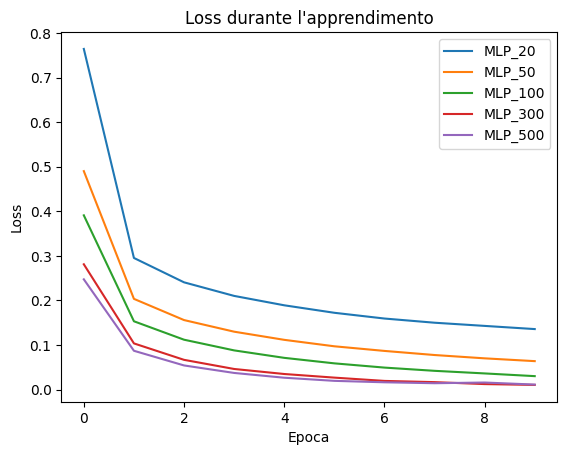

In [8]:
_ = plt.plot(range(MLP_20.n_iter_), MLP_20.loss_curve_, label='MLP_20')
_ = plt.plot(range(MLP_50.n_iter_), MLP_50.loss_curve_, label='MLP_50')
_ = plt.plot(range(MLP_100.n_iter_), MLP_100.loss_curve_, label='MLP_100')
_ = plt.plot(range(MLP_300.n_iter_), MLP_300.loss_curve_, label='MLP_300')
_ = plt.plot(range(MLP_500.n_iter_), MLP_500.loss_curve_, label='MLP_500')
_ = plt.xlabel("Epoca")
_ = plt.ylabel("Loss")
_ = plt.title("Loss durante l'apprendimento")
_ = plt.legend()

print("Accuracy MLP_20 =", MLP_20.score(x_te, mnist_te_labels))
print("Accuracy MLP_50 =", MLP_50.score(x_te, mnist_te_labels))
print("Accuracy MLP_100 =", MLP_100.score(x_te, mnist_te_labels))
print("Accuracy MLP_300 =", MLP_300.score(x_te, mnist_te_labels))
print("Accuracy MLP_500 =", MLP_500.score(x_te, mnist_te_labels))


È innanzitutto importante osservare come l'utilizzare pochi neuroni (20) in due strati nascosti permetta di avere un'accuracy piuttosto alta, superiore al 95%, seppur avendo una loss alta.

In secondo luogo, si può osservare come l'addestramento del modello porta ad una diminuzione della loss function con un andamento molto simile al variare del numero di neuroni negli strati nascosti.

Si può poi osservare come i modelli con meno neuroni negli strati nascosti richiedano un maggior numero di epoche di addestramento per raggiungere il minimo.

Inoltre, dal grafico possiamo osservare che sembra esistere un plateau per la funzione di loss che non può essere superato semplicemente continuando ad aumentare il numero di neuroni negli strati nascosti. Per cercare di ottenere performance maggiori, potrebbe essere maggiormente sensato modificare l'architettura o altri iperparametri.

Mostriamo ora un grafico che relazioni, per questo esempio di rete MLP, il numero di neuroni negli strati nascosti e l'accuracy.

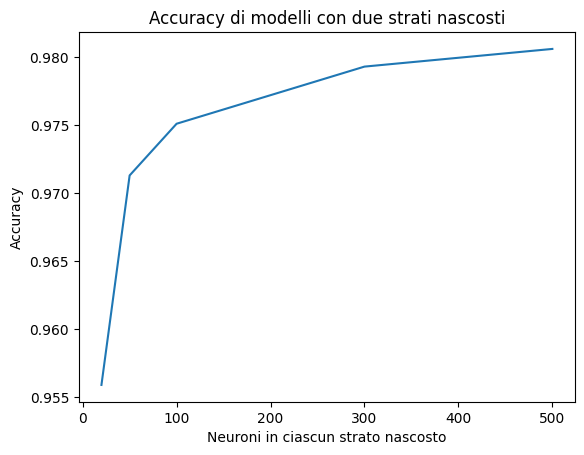

In [9]:
a = [20,50,100,300,500]
b = [MLP_20.score(x_te, mnist_te_labels),
    MLP_50.score(x_te, mnist_te_labels),
    MLP_100.score(x_te, mnist_te_labels),
    MLP_300.score(x_te, mnist_te_labels),
    MLP_500.score(x_te, mnist_te_labels)]


_ = plt.plot(a,b)
_ = plt.xlabel("Neuroni in ciascun strato nascosto")
_ = plt.ylabel("Accuracy")
_ = plt.title("Accuracy di modelli con due strati nascosti")


Si può osservare come un aumento lineare del numero di neuroni (e quindi un aumento - non necessariamente lineare - delle risorse richieste per l'addestramento) porti progressivamente a miglioramenti sempre più esigui, non giustificando le risorse aggiuntive richieste per l'addestramento.

Proviamo ora a vedere se l'architettura abbia influenza sulle performance del modello.
Proviamo ad addestrare altre reti da confrontare, mantenendo lo stesso numero di neuroni ma diverso numero strati nascosti.

Prendiamo come riferimento il precedente modello MLP_100, costituito da due strati nascosti di 100 neuroni ciascuno.
Proviamo ad addestrare una rete con un singolo strato nascosto da 200 neuroni, una rete da 3 strati nascosti da 66 neuroni l'uno e una da 4 strati nascosti da 50 neuroni l'uno.


/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy MLP_200_H1 = 0.9784
Accuracy MLP_66_H3 = 0.9702
Accuracy MLP_50_H4 = 0.9716


/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


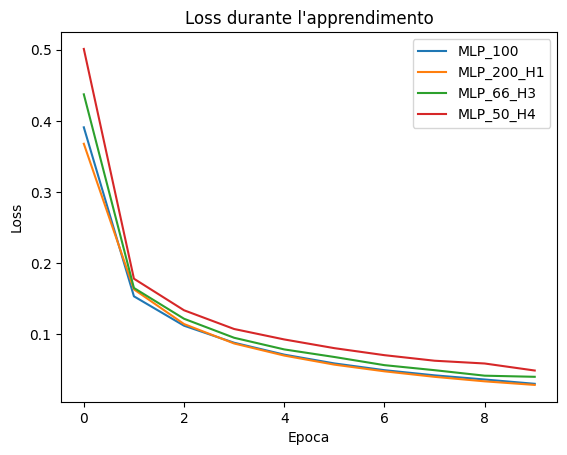

In [10]:
MLP_200_H1 = MLPClassifier(hidden_layer_sizes=(200),
                    max_iter = 10,
                    random_state=random_state)
MLP_66_H3 = MLPClassifier(hidden_layer_sizes=(66,66,66),
                    max_iter = 10,
                    random_state=random_state)
MLP_50_H4 = MLPClassifier(hidden_layer_sizes=(50,50,50,50),
                    max_iter = 10,
                    random_state=random_state)

MLP_200_H1 = MLP_200_H1.fit(x_tr, mnist_tr_labels)
MLP_66_H3 = MLP_66_H3.fit(x_tr, mnist_tr_labels)
MLP_50_H4 = MLP_50_H4.fit(x_tr, mnist_tr_labels)
print("Accuracy MLP_200_H1 =", MLP_200_H1.score(x_te, mnist_te_labels))
print("Accuracy MLP_66_H3 =", MLP_66_H3.score(x_te, mnist_te_labels))
print("Accuracy MLP_50_H4 =", MLP_50_H4.score(x_te, mnist_te_labels))

_ = plt.plot(range(MLP_100.n_iter_), MLP_100.loss_curve_, label='MLP_100')
_ = plt.plot(range(MLP_200_H1.n_iter_), MLP_200_H1.loss_curve_, label='MLP_200_H1')
_ = plt.plot(range(MLP_66_H3.n_iter_), MLP_66_H3.loss_curve_, label='MLP_66_H3')
_ = plt.plot(range(MLP_50_H4.n_iter_), MLP_50_H4.loss_curve_, label='MLP_50_H4')
_ = plt.xlabel("Epoca")
_ = plt.ylabel("Loss")
_ = plt.title("Loss durante l'apprendimento")
_ = plt.legend()

Dal grafico si evince che, sebbene l'accuracy del modello rimanga stabile, aumentando il numero di strati nascosti la funzione di loss sembri essere leggermente più alta. Questo potrebbe indicare che i strati nascosti aggiuntivi forse non siano realmente necessari, anche perché, come sappiamo, possono indurre a overfitting.

Analizziamo infine quali altri iperparametri hanno molta influenza sulle performance del modello.

/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy MLP_100_lr = 0.9677
Accuracy MLP_100_logistic = 0.9701


/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


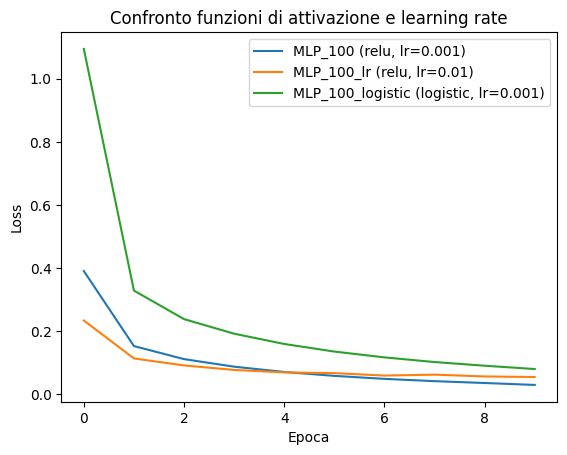

In [11]:
MLP100_lr = MLPClassifier(hidden_layer_sizes=(100, 100),
                    learning_rate_init=0.01,
                    max_iter = 10,
                    random_state=random_state)

MLP100_logistic = MLPClassifier(hidden_layer_sizes=(100, 100),
                    activation='logistic',
                    max_iter = 10,
                    random_state=random_state)

MLP_100_lr = MLP100_lr.fit(x_tr, mnist_tr_labels)
MLP_100_logistic = MLP100_logistic.fit(x_tr, mnist_tr_labels)

print("Accuracy MLP_100_lr =", MLP_100_lr.score(x_te, mnist_te_labels))
print("Accuracy MLP_100_logistic =", MLP_100_logistic.score(x_te, mnist_te_labels))

_ = plt.plot(range(MLP_100.n_iter_), MLP_100.loss_curve_, label='MLP_100 (relu, lr=0.001)')
_ = plt.plot(range(MLP_100_lr.n_iter_), MLP_100_lr.loss_curve_, label='MLP_100_lr (relu, lr=0.01)')
_ = plt.plot(range(MLP_100_logistic.n_iter_), MLP_100_logistic.loss_curve_, label='MLP_100_logistic (logistic, lr=0.001)')
_ = plt.xlabel("Epoca")
_ = plt.ylabel("Loss")
_ = plt.title("Confronto funzioni di attivazione e learning rate")
_ = plt.legend()

Possiamo osseravare comportamenti attesi: la scelta della funzione di attivazione dei neuroni negli strati nascosti ha un impatto non indifferente. Inoltre, anche un tasso di apprendimento "sbagliato" si comporta come previsto: nelle prime epoche l'addesetramento fa molti progressi nella discesa del gradiente, ma non raggiunge un minimo (locale o globale) in quanto il "passo" di discesa è troppo grande e quindi "salta" il minimo, superandolo.

Per riassumere, i fattori che possono influenzare l'addestramento possono essere (lista non esaustiva):
- L'architettura della rete, intesa numero di neuroni, numero di strati nascosti e, di conseguenza, numero di connessioni.
- Gli iperparametri, tra cui, in maniera significativa, la funzione di attivazione dei neuroni negli strati nascosti e il tasso di apprendimento.

## Analisi degli errori di classificazione (b)

Prendiamo in esame il modello MLP_500.

Analizziamo la matrice di confusione per determinare quali siano gli errori di classificazione effettuati dal modello.

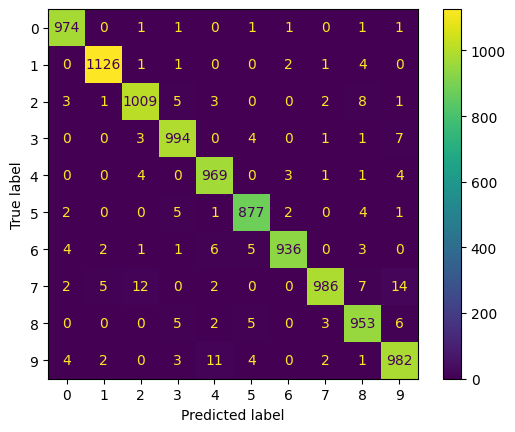

In [12]:
x_te_predictions_500 = MLP_500.predict(x_te)
_ = metrics.ConfusionMatrixDisplay.from_predictions(mnist_te_labels, x_te_predictions_500)

Osserviamo come il modello commetta errori di classificazioni dovuti alla somiglianza tra le cifre. Esempi notevoli sono il classificare i 7 come 2, i 9 come 4 e i 7 come 9. Procediamo a vedere quali sono gli esempi in queste categorie che sono stati classificati in maniera errata.

In [13]:
def print_figure_list(array, idx_array, true, pred, title="", limit=30):
    #n = len(idx_array)
    cols = 6
    rows = (limit + cols - 1) // cols

    plt.figure(figsize=(1.5 * cols, 1.5 * rows))

    for idx, img_idx in enumerate(idx_array[:limit]):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(array[img_idx].reshape(28, 28), cmap="bone")
        plt.axis("off")

    plt.suptitle(title if title else f"{true} classificati come {pred}")
    plt.subplots_adjust(top=0.9)
    plt.show()

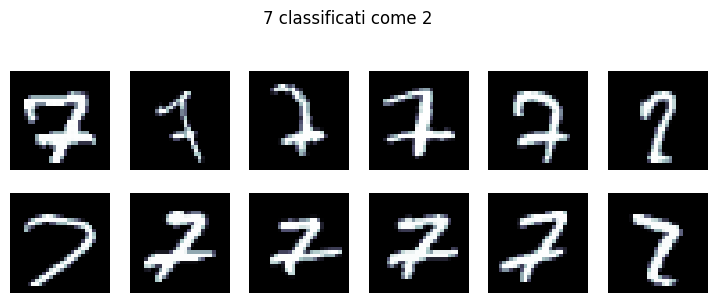

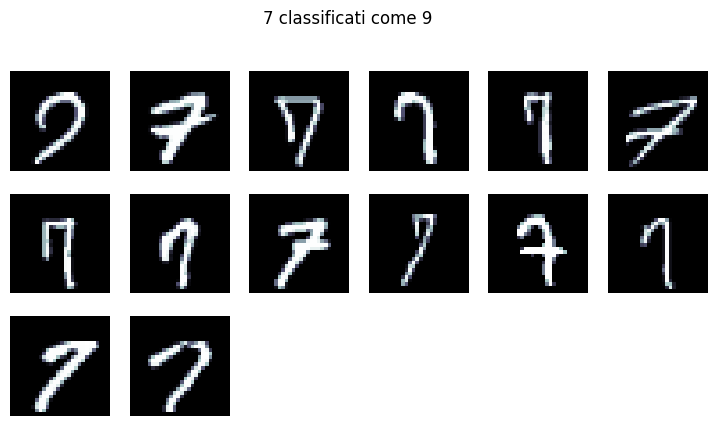

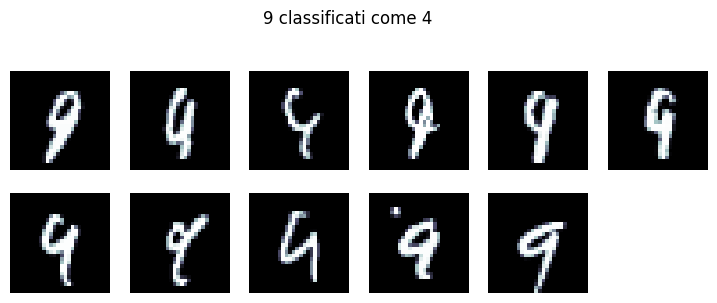

In [14]:
wrong_predictions_idx = np.where(x_te_predictions_500 != mnist_te_labels)[0]

predicted7as2 = [i for i in wrong_predictions_idx if mnist_te_labels[i] == 7 and x_te_predictions_500[i] == 2]
predicted7as9 = [i for i in wrong_predictions_idx if mnist_te_labels[i] == 7 and x_te_predictions_500[i] == 9]
predicted9as4 = [i for i in wrong_predictions_idx if mnist_te_labels[i] == 9 and x_te_predictions_500[i] == 4]
print_figure_list(x_te, predicted7as2, 7, 2)
print_figure_list(x_te, predicted7as9, 7, 9)
print_figure_list(x_te, predicted9as4, 9, 4)

Si può osservare che alcuni errori di classificazione sono in parte comprensibili e dovuti ad una certa ambiguità dovuta alla calligrafia, ad esempio per i 9 classificati come 4. Tuttavia, ci sono esempi che sono maggiormente comprensibili per un essere umano, come i 7 classificati come 2, mentre il modello ha difficoltà maggiori. Invece, è interessante osservare come gli esempi di 7 classificati come 9 hanno tutti una forma simile, con un una barra in alto a sinistra che scende e l'assenza della linea orizzontale a metà tipica del 7 scritto a mano.

## Rumore nei pattern di test (c)

Procediamo ad aggiungere gradualmente (a passi di 0.1, da 0.0 a 2.0) del rumore gaussiano negli esempi di test e analizziamo come variano le performance del modello. Data la variabilità del rumore, ripetiamo l'esperimento, a parità di rumore, un numero sufficiente di volte (10) per cercare di ottenere un valore dell'accuracy del modello più stabile.

In [15]:
sigmas = np.linspace(0.0, 2.0, 11)
noisy_accuracy = []
noise_figure = []

for sigma in sigmas:
    acc = []
    for _ in range(10):
        noise = np.random.normal(loc=0.0, scale=sigma, size=x_te.shape)
        x_noisy = np.clip(x_te + noise, 0.0, 1.0)
        acc.append(MLP_500.score(x_noisy, mnist_te_labels))
    noisy_accuracy.append(np.mean(acc))

    noise = np.random.normal(loc=0.0, scale=sigma, size=x_te.shape)
    x_noisy = np.clip(x_te + noise, 0.0, 1.0) # per mantenere la normalizzazione
    noise_figure.append(x_noisy[0])

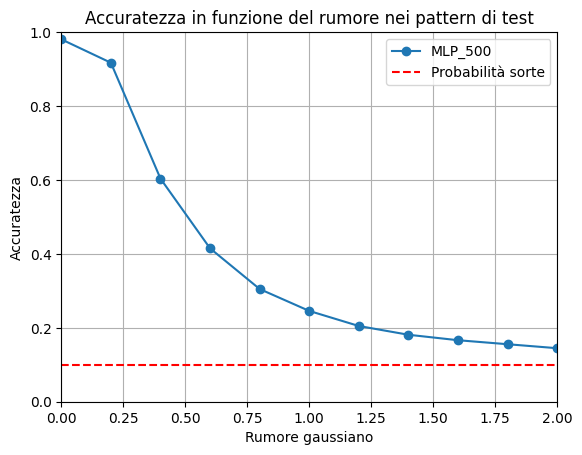

In [16]:
plt.plot(sigmas, noisy_accuracy, label='MLP_500' ,marker='o')
plt.axhline(1/10, ls='--', color='red', label='Probabilità sorte')
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 1.0)
plt.xlabel('Rumore gaussiano')
plt.ylabel('Accuratezza')
plt.title('Accuratezza in funzione del rumore nei pattern di test')
plt.legend()
plt.grid(True)
plt.show()


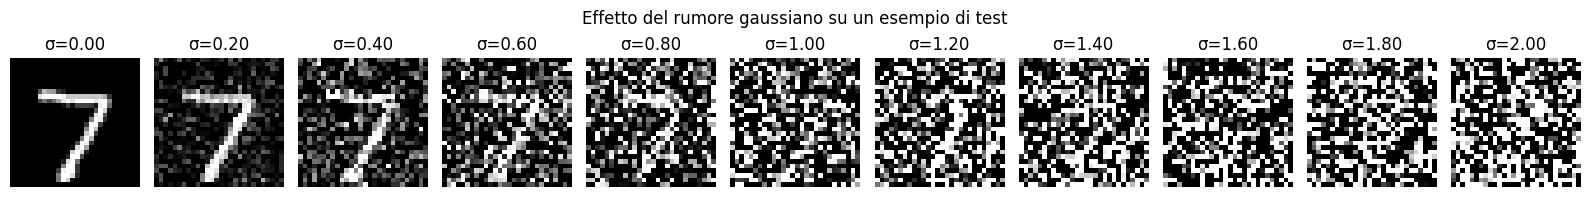

In [17]:
plt.figure(figsize=(16, 2))
for i, (img, sigma) in enumerate(zip(noise_figure, sigmas)):
    plt.subplot(1, len(sigmas), i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"σ={sigma:.2f}")
    plt.axis('off')
plt.suptitle("Effetto del rumore gaussiano su un esempio di test")
plt.tight_layout()
plt.show()

È interessante osservare come inizialmente le performance del modello deprecano lentamente per valori molto bassi del rumore, per poi deprecare molto velocemente una volta superata una certa soglia di rumore nei pattern di test, per poi infine rallentare gradualmente, peggiorando sempre più lentamente.
Tuttavia si può anche osservare che, anche con un rumore piuttosto elevato, il modello riesce a fare comunque meglio (seppur di poco) dell'indovinare a sorte. Ad esempio, per valori di sigma elevati è molto difficile riconoscere la cifra presa sopra come esempio anche per un essere umano.

## Riduzione dei pattern di training (d)

Osserviamo ora come si comporta il modello qualora venisse utilizzato un numero inferiore di pattern di addestramento. Ci attendiamo una riduzione della accuracy. Per cercare di rendere l'esperimento più equo possibile, utilizziamo una funzione di libreria per dividere i pattern di training, in modo bilanciato rispetto al numero di classi e ripetibile tramite random state.

Per semplicità di calcolo, per questo test ci baseremo su MLP_300.

/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

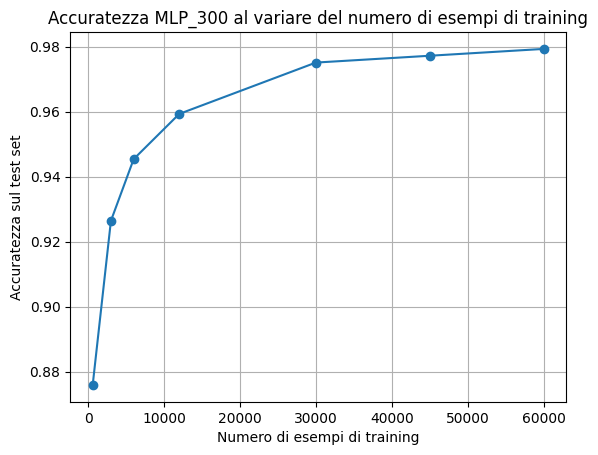

In [18]:
from sklearn.model_selection import train_test_split

fractions = [0.01, 0.05, 0.1, 0.2, 0.5, 0.75]
accuracies = []

for frac in fractions:
    x_small, _, y_small, _ = train_test_split(x_tr, mnist_tr_labels,
                                              train_size=frac, stratify=mnist_tr_labels, random_state=random_state)
    MLP300_small = MLPClassifier(hidden_layer_sizes=(300, 300),
                    max_iter = 10,
                    random_state=random_state)

    MLP_300_small = MLP300_small.fit(x_small, y_small)
    accuracies.append(MLP_300_small.score(x_te, mnist_te_labels))

fractions.append(1.0)
accuracies.append(MLP_300.score(x_te, mnist_te_labels))

plt.plot([int(60000*f) for f in fractions], accuracies, label='MLP_300 addestrata su x pattern di training', marker='o')
plt.xlabel("Numero di esempi di training")
plt.ylabel("Accuratezza sul test set")
plt.title("Accuratezza MLP_300 al variare del numero di esempi di training")
plt.grid(True)
plt.show()


Si può osservare come il miglioramento dei modelli addestrati con pari numero di neuroni e di strati intermedi sia inversamente proporzionale al numero di pattern utilizzati durante l'addestramento. In particolare, si può osservare che basta un numero piuttosto basso di pattern di training (nell'ordine delle migliaia) per avere performance ragionevoli. Inoltre, si può osservare che da un certo in punto in poi, l'aumento del numero di pattern di training porti a benefici sempre più scarsi, in modo molto simile a quanto osservato al variare del numero di neuroni negli strati intermedi.

## Rumore nei pattern di training (e)

Vediamo infine cosa succede se, oltre ad inserire del rumore nei pattern di test, lo inseriamo anche nei pattern di training. Ci si aspetta un miglioramento, anche se difficile da quantificare. Al momento, per semplicità, studiamo il caso in cui il rumore gaussiano utilizzato nei pattern di training sia pari a 0.3 e vediamo come si comporta il modello al variare del rumore nei pattern di test.

Anche qui, per semplicità di calcolo, ci baseremo su MLP_300

/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


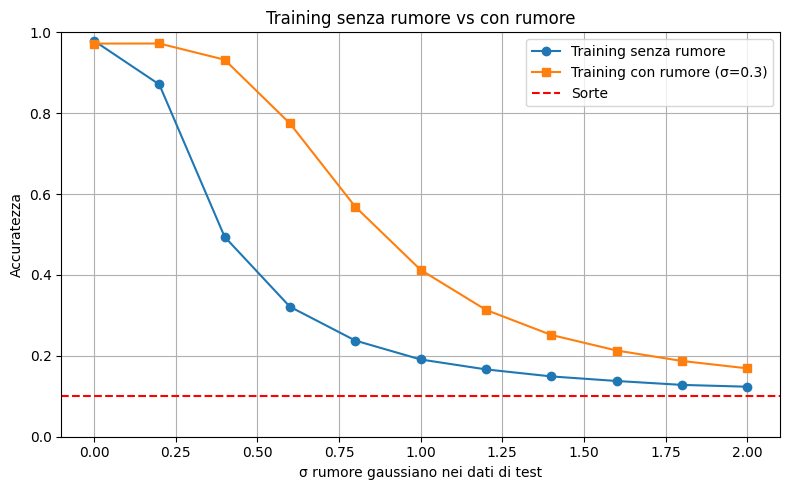

In [19]:
sigma_train = 0.3 
noise = np.random.normal(loc=0.0, scale=sigma_train, size=x_tr.shape)
x_tr_noisy = np.clip(x_tr + noise, 0.0, 1.0)

# Addestramento con dati rumorosi
MLP_300_noisy = MLPClassifier(hidden_layer_sizes=(300, 300),
                              max_iter=10,
                              random_state=random_state)
MLP_300_noisy.fit(x_tr_noisy, mnist_tr_labels)

sigmas = np.linspace(0.0, 2.0, 11)
acc_clean = []
acc_noise_03= []

for sigma in sigmas:
    acc_c = []
    acc_n = []
    for _ in range(10):
        noise = np.random.normal(loc=0.0, scale=sigma, size=x_te.shape)
        x_te_noisy = np.clip(x_te + noise, 0.0, 1.0)

        acc_c.append(MLP_300.score(x_te_noisy, mnist_te_labels))
        acc_n.append(MLP_300_noisy.score(x_te_noisy, mnist_te_labels))

    acc_clean.append(np.mean(acc_c))
    acc_noise_03.append(np.mean(acc_n))

plt.figure(figsize=(8,5))
plt.plot(sigmas, acc_clean, label='Training senza rumore', marker='o')
plt.plot(sigmas, acc_noise_03, label=f'Training con rumore (σ={sigma_train})', marker='s')
plt.axhline(1/10, ls='--', color='red', label='Sorte')
plt.xlabel("σ rumore gaussiano nei dati di test")
plt.ylabel("Accuratezza")
plt.title("Training senza rumore vs con rumore")
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


Osserviamo che inserendo del rumore con sigma=0.3 nei pattern di training, l'accuratezza del modello è sensibilmente più alta per valori medio-bassi (a partire da 0.3) del rumore nei dati di test. Tuttavia, questo incremento di accuratezza decresce gradualmente all'aumentare del rumore nei pattern di test. Sarebbe altrettanto interessante analizzare l'accuratezza del modello utilizzando la stessa quantità di rumore sia nei pattern di training, sia nei pattern di test. Tuttavia, ciò richiede l'addestramento di un nuovo modello per ciascun valore da analizzare del rumore, pertanto, per via della complessità computazionale, analizzeremo solo pochi casi.  

In [20]:
sigmas = np.linspace(0.0, 2.0, 11)
acc_noise_sigma = []

for sigma in sigmas:
    noise_tr = np.random.normal(loc=0.0, scale=sigma, size=x_tr.shape)
    x_tr_noisy = np.clip(x_tr + noise_tr, 0.0, 1.0)

    MLP_300_noisy = MLPClassifier(hidden_layer_sizes=(300, 300), max_iter=10, random_state=0)
    MLP_300_noisy.fit(x_tr_noisy, mnist_tr_labels)

    acc = []
    for _ in range(10):
        noise_te = np.random.normal(loc=0.0, scale=sigma, size=x_te.shape)
        x_te_noisy = np.clip(x_te + noise_te, 0.0, 1.0)
        acc.append(MLP_300_noisy.score(x_te_noisy, mnist_te_labels))

    acc_noise_sigma.append(np.mean(acc))


/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

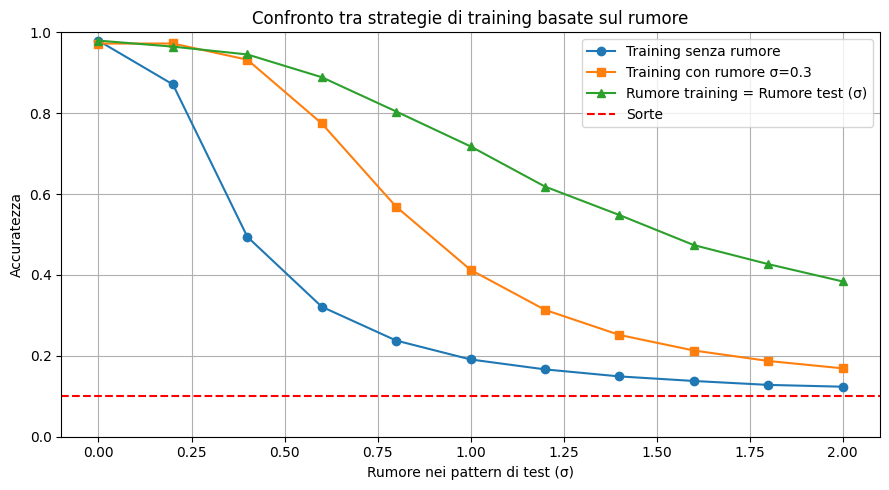

In [21]:
plt.figure(figsize=(9,5))
plt.plot(np.linspace(0.0, 2.0, 11), acc_clean, label='Training senza rumore', marker='o')
plt.plot(np.linspace(0.0, 2.0, 11), acc_noise_03, label='Training con rumore σ=0.3', marker='s')
plt.plot(sigmas, acc_noise_sigma, label='Rumore training = Rumore test (σ)', marker='^')
plt.axhline(1/10, ls='--', color='red', label='Sorte')

plt.xlabel("Rumore nei pattern di test (σ)")
plt.ylabel("Accuratezza")
plt.title("Confronto tra strategie di training basate sul rumore")
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


Risulta interessante osservare come i modelli addestrati con rumore elevato siano molto efficaci nel riconoscimento di esempi con qualsiasi quantità di rumore, e, sebbene non possano avere perfomance elevate anche nel caso di rumore molto elevato, risultano avere performance molto più alte (più del doppio per valori di sigma elevati) di modelli addestrati con rumore basso o nullo.
Ricordiamo le osservazioni fatte nel punto C di questo studio e possiamo renderci conto che le reti neurali addestrate opportunamente possano risultare uno strumento molto potente, in grado di superare le capacità del cervello umano.

Tuttavia, bisogna prestare attenzione a non sovrastimare le capacità di generalizzazione di questi modelli. Infatti, per ottenere risultati più precisi, sarebbe necessario separare il dataset in tre parti: una per il training, una per la validazione e una per il test, eventualmente utilizzando anche tecniche per la prevenzione di overfitting come cross-validation e early-stopping. Tuttavia, i risultati ottenuti sembrano promettenti.

# Fashion MNIST

Proviamo ad estendere le simulazioni al dataset FashionMNIST.

In [22]:
from torchvision.datasets import FashionMNIST

fashion_mnist_tr = FashionMNIST(root="../fashion_mnist",
                 train=True,      # dati di training
                 download=True)
fashion_mnist_te = FashionMNIST(root="../fashion_mnist",
                 train=False,     # dati di test
                 download=True)

fashion_mnist_tr, fashion_mnist_tr_labels = fashion_mnist_tr.data.numpy(), fashion_mnist_tr.targets.numpy()
fashion_mnist_te, fashion_mnist_te_labels = fashion_mnist_te.data.numpy(), fashion_mnist_te.targets.numpy()

In [23]:
fashion_x_tr = fashion_mnist_tr.reshape(60000, 28 * 28)
fashion_x_te = fashion_mnist_te.reshape(10000, 28 * 28)

fashion_x_tr = fashion_x_tr / 255.0  # il .0 serve a forzare la conversione in float, anche se potrebbe pensarci già python
fashion_x_te = fashion_x_te / 255.0

In [24]:
MLP500_fashion = MLPClassifier(hidden_layer_sizes=(500, 500),
                    max_iter = 10,
                    random_state=random_state)

MLP_500_fashion = MLP500_fashion.fit(fashion_x_tr, fashion_mnist_tr_labels)

/home/stef/Documenti/ia/.venv/lib64/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy MLP_500_fashion = 0.8885


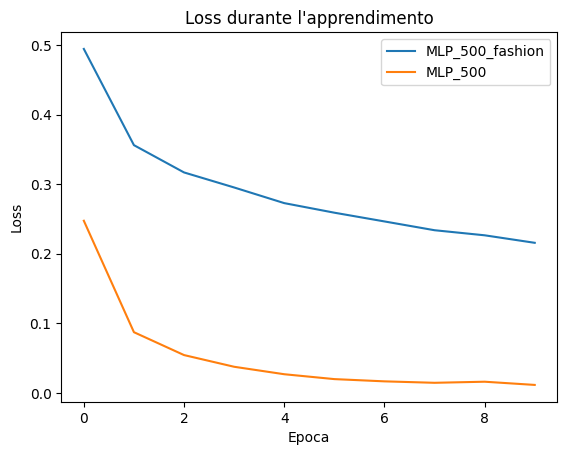

In [25]:
_ = plt.plot(range(MLP_500_fashion.n_iter_), MLP_500_fashion.loss_curve_, label='MLP_500_fashion')
_ = plt.plot(range(MLP_500.n_iter_), MLP_500.loss_curve_, label='MLP_500')
_ = plt.xlabel("Epoca")
_ = plt.ylabel("Loss")
_ = plt.title("Loss durante l'apprendimento")
_ = plt.legend()

print("Accuracy MLP_500_fashion =", MLP_500_fashion.score(fashion_x_te, fashion_mnist_te_labels))


A prima vista si può osservare che un modello identico addestrato su Fashion MNIST abbia performance inferiori rispetto a quello delle semplici cifre manoscritte, sia in termini di accuracy, che di loss. Si può osservare inoltre che la curva di errore abbia una forma diversa da quella analoga per MNIST, e che il numero di epoche non sia sufficiente per raggiungere un minimo.

Analizziamo ora la matrice di confusione.

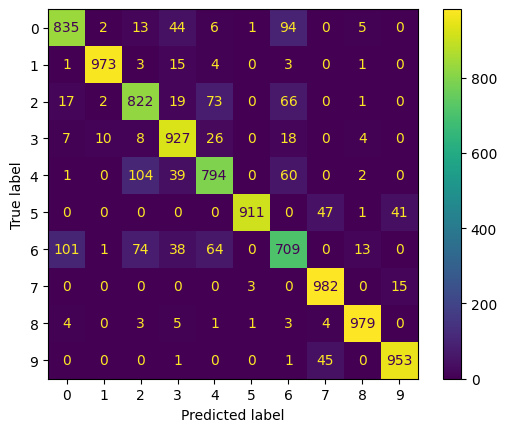

In [26]:
fashion_x_te_predictions_500 = MLP_500_fashion.predict(fashion_x_te)
_ = metrics.ConfusionMatrixDisplay.from_predictions(fashion_mnist_te_labels, fashion_x_te_predictions_500)

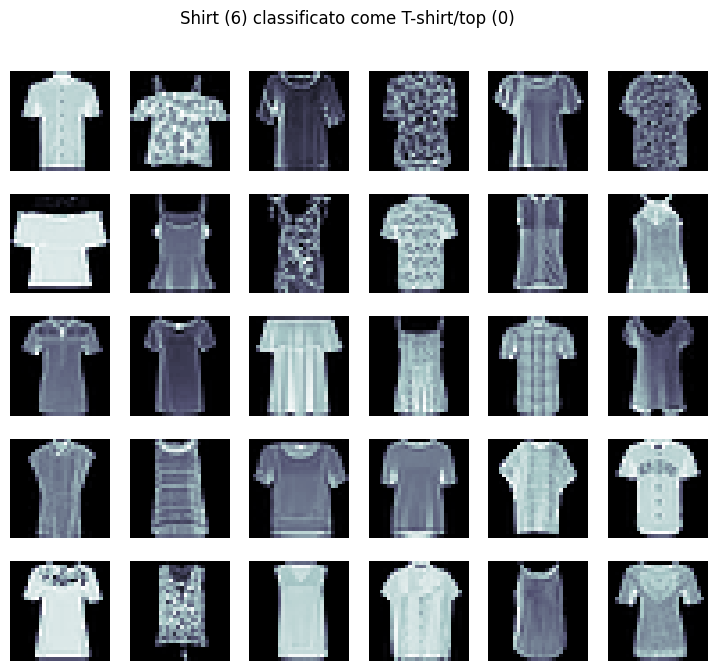

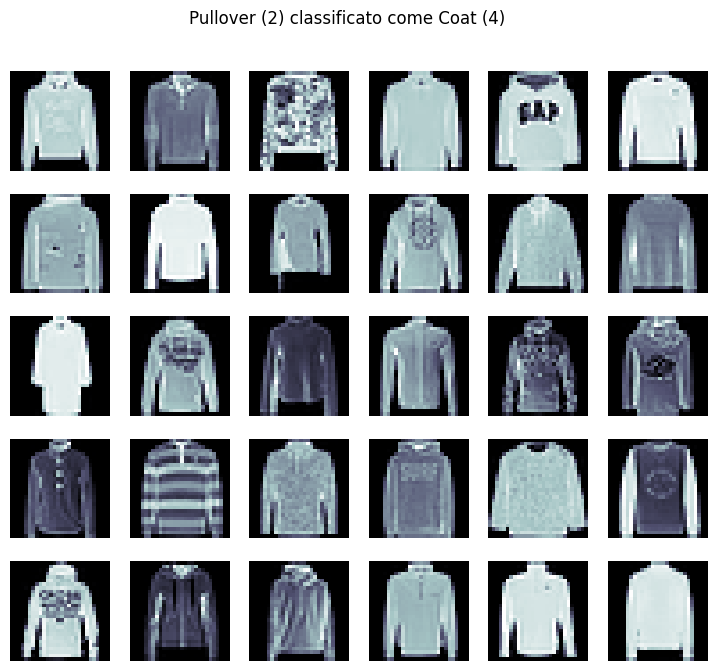

In [27]:
fashion_wrong_predictions_idx = np.where(fashion_x_te_predictions_500 != fashion_mnist_te_labels)[0]

fashion_predicted6as0 = [i for i in fashion_wrong_predictions_idx if fashion_mnist_te_labels[i] == 6 and fashion_x_te_predictions_500[i] == 0]
fashion_predicted2as4 = [i for i in fashion_wrong_predictions_idx if fashion_mnist_te_labels[i] == 2 and fashion_x_te_predictions_500[i] == 4]
print_figure_list(fashion_mnist_te, fashion_predicted6as0, 6, 0, "Shirt (6) classificato come T-shirt/top (0)")
print_figure_list(fashion_mnist_te, fashion_predicted2as4, 2, 4, "Pullover (2) classificato come Coat (4)")

Risulta evidente come il modello faccia fatica a distinguere abiti dalla forma simile, e dalla matrice di confusione si possono osservare molti casi di confusione tra classi.

Sembra essere proprio qui che si possono incontrare i limiti delle reti MLP: è probabile che un tipo di rete più adatta al riconoscimento di immagini come CNN possa offrire delle prestazioni maggiori.

# Note finali

I modelli sono stati addestrati in locale su una CPU AMD Ryzen 7 6800HS, dando performance ragionevoli per l'addestramento dei singoli modelli. L'ultimo grafico del punto 'e' è stato il più oneroso e ha richiesto 6 minuti di calcolo.

È stato usato un ambiente virtuale con Python 3.10.19